
# prospective decay kernel scenario plots with uncertainty and IPCC benchmark

This notebook creates a **3-row stacked figure** for **CO$_2$**, **CH$_4$**, and **N$_2$O** using the same pIRF outputs already used in the earlier notebooks.

## What is plotted
- **FaIR-based prospective decay curves** for selected SSPs at a chosen **ModelYear** (`BAND_MY`)
- **Uncertainty bands** from the ensemble pickle for the same `BAND_MY`
- **IPCC analytical CO$_2$ IRF** as a single dashed gray line in the CO$_2$ panel only

## What is not plotted
- No Watanabe & Cherubini comparison lines
- No scenario mapping to RCPs

## Inputs expected in the subfolder `pIRF`: 
- `pirf_median_by_ssp-all_H200_MY2030.xlsx`
- `pirf_median_by_ssp-all_H200_MY2040.xlsx`
- `pirf_median_by_ssp-all_H200_MY2050.xlsx`
- `pirf_by_ssp-all_H200_MY2030_ens.pkl`
- `pirf_by_ssp-all_H200_MY2040_ens.pkl`
- `pirf_by_ssp-all_H200_MY2050_ens.pkl`


In [1]:
from pathlib import Path
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import os

In [2]:
# ----------------------------
# User settings
# ----------------------------
BAND_MY = "2030"            # choose from: "2030", "2040", "2050" used for just 1*3 plot 
BAND_Q_LO = 0.01            # e.g., 0.01 for 1st percentile
BAND_Q_HI = 0.99            # e.g., 0.99 for 99th percentile
H_MAX = 200                 # maximum time horizon shown
SAVE_FIG = True

# scenario colors aligned to the concentration plot logic
SCENARIO_COLORS = {
    "ssp119": "#2ca02c",    # green
    "ssp126": "#1f77b4",    # blue
    "ssp245": "#ff7f0e",    # orange
    "ssp460": "#9467bd",    # purple
    "ssp585": "#9e9e9e",    # grey
}

SCENARIO_LABELS = {
    "ssp119": "SSP1-1.9",
    "ssp126": "SSP1-2.6",
    "ssp245": "SSP2-4.5",
    "ssp460": "SSP4-6.0",
    "ssp585": "SSP5-8.5",
}

# choose the scenarios to plot
SCENARIOS = ["ssp119", "ssp126", "ssp245", "ssp585"]
GASES = ["CO2", "CH4", "N2O"]

# anchor everything to the notebook working directory
ROOT = Path.cwd()

paths_my = {
    "2030": ROOT / "pirf_median_by_ssp-all_H200_MY2030.xlsx",
    "2040": ROOT / "pirf_median_by_ssp-all_H200_MY2040.xlsx",
    "2050": ROOT / "pirf_median_by_ssp-all_H200_MY2050.xlsx",
}

paths_my_ens = {
    "2030": ROOT / "pirf_by_ssp-all_H200_MY2030_ens.pkl",
    "2040": ROOT / "pirf_by_ssp-all_H200_MY2040_ens.pkl",
    "2050": ROOT / "pirf_by_ssp-all_H200_MY2050_ens.pkl",
}

#print("Current working directory:", ROOT)

for p in list(paths_my.values()) + list(paths_my_ens.values()):
    print(p, "->", p.exists())
    if not p.exists():
        raise FileNotFoundError(f"Missing required input file: {p}")

out_dir = ROOT / "pIRF_plot_stacked_uncertainty_IPCC"
out_dir.mkdir(exist_ok=True)
print(f"Output folder: {out_dir}")


/Users/susierwu/dpLCA_main/dpLCIA/FaIR_dpCFs/output/pIRF/pirf_median_by_ssp-all_H200_MY2030.xlsx -> True
/Users/susierwu/dpLCA_main/dpLCIA/FaIR_dpCFs/output/pIRF/pirf_median_by_ssp-all_H200_MY2040.xlsx -> True
/Users/susierwu/dpLCA_main/dpLCIA/FaIR_dpCFs/output/pIRF/pirf_median_by_ssp-all_H200_MY2050.xlsx -> True
/Users/susierwu/dpLCA_main/dpLCIA/FaIR_dpCFs/output/pIRF/pirf_by_ssp-all_H200_MY2030_ens.pkl -> True
/Users/susierwu/dpLCA_main/dpLCIA/FaIR_dpCFs/output/pIRF/pirf_by_ssp-all_H200_MY2040_ens.pkl -> True
/Users/susierwu/dpLCA_main/dpLCIA/FaIR_dpCFs/output/pIRF/pirf_by_ssp-all_H200_MY2050_ens.pkl -> True
Output folder: /Users/susierwu/dpLCA_main/dpLCIA/FaIR_dpCFs/output/pIRF/pIRF_plot_stacked_uncertainty_IPCC


In [3]:

# ----------------------------
# IPCC analytical CO2 IRF
# ----------------------------
IPCC_A = np.array([0.2173, 0.2240, 0.2824, 0.2763])       # a0, a1, a2, a3
IPCC_ALPHA_CO2 = np.array([0.0, 394.4, 36.54, 4.304])    # years; slot 0 unused

H_ipcc = np.arange(0, H_MAX + 1, 1)
pIRF_ipcc = (
    IPCC_A[0]
    + IPCC_A[1] * np.exp(-H_ipcc / IPCC_ALPHA_CO2[1])
    + IPCC_A[2] * np.exp(-H_ipcc / IPCC_ALPHA_CO2[2])
    + IPCC_A[3] * np.exp(-H_ipcc / IPCC_ALPHA_CO2[3])
)

pIRF_ipcc[:5]


array([1.        , 0.93452514, 0.88113392, 0.8373585 , 0.80124169])

### 3*3 plot 

Median data loaded for: 2030, 2040, 2050
Ensemble data loaded for: 2030, 2040, 2050
Saved figure to:
 - /Users/susierwu/dpLCA_main/dpLCIA/FaIR_dpCFs/output/pIRF/pIRF_plot_stacked_uncertainty_IPCC/pIRF_grid_uncertainty_IPCC_MY2030_2040_2050.png
 - /Users/susierwu/dpLCA_main/dpLCIA/FaIR_dpCFs/output/pIRF/pIRF_plot_stacked_uncertainty_IPCC/pIRF_grid_uncertainty_IPCC_MY2030_2040_2050.pdf


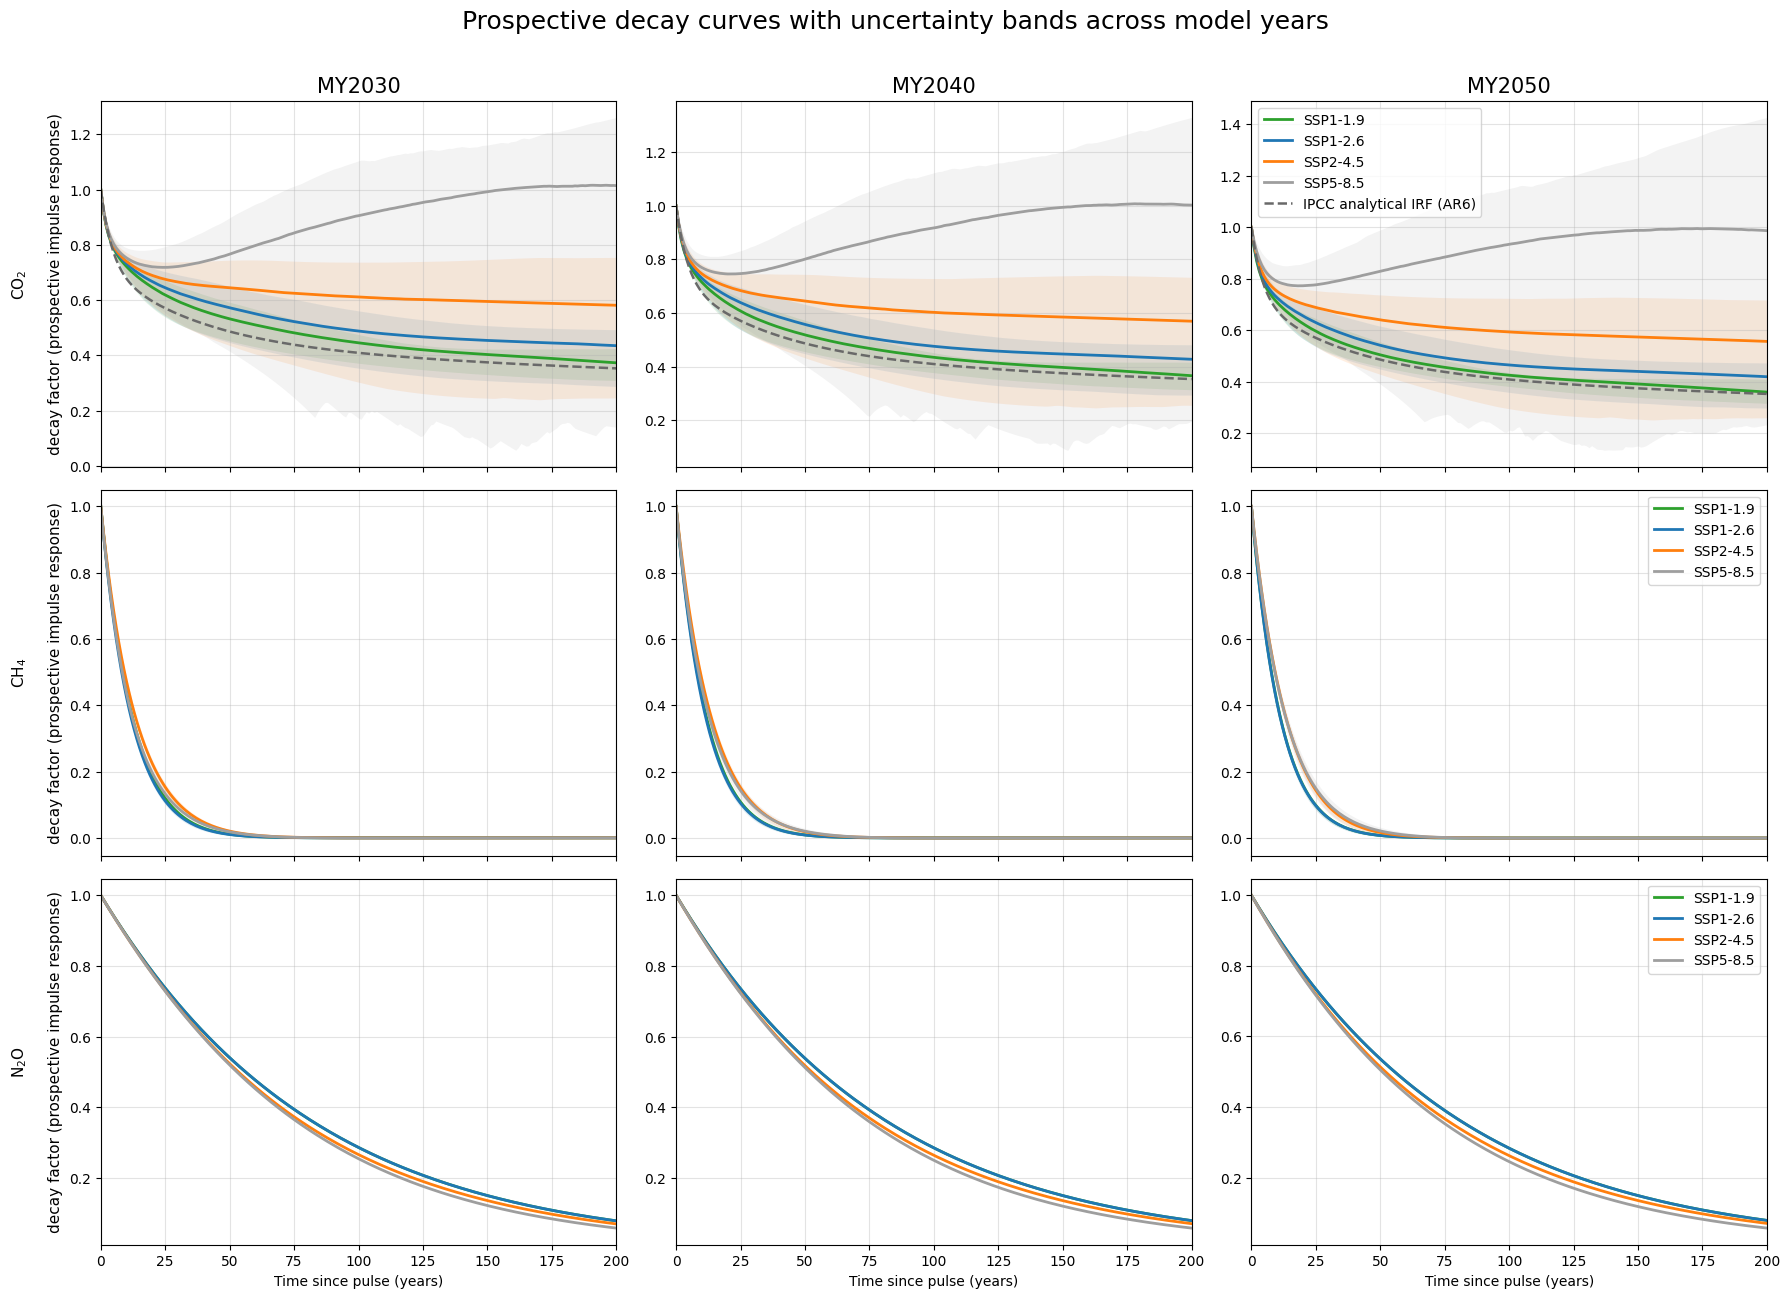

In [4]:
from pathlib import Path
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ----------------------------
# Helpers
# ----------------------------
def detect_cols(df):
    df = df.copy()
    df.columns = [str(c) for c in df.columns]

    col_gas = [c for c in df.columns if c.lower() == "gas"][0]
    col_ssp = [c for c in df.columns if ("ssp" in c.lower()) or ("scenario" in c.lower())][0]
    col_h   = [c for c in df.columns if c.lower() in ["h", "horizon", "time", "t", "year"]][0]
    col_val = [c for c in df.columns if c.lower() in ["value", "median", "pirf"]][0]
    return col_gas, col_ssp, col_h, col_val

def gas_title(gas):
    return {"CO2": "CO$_2$", "CH4": "CH$_4$", "N2O": "N$_2$O"}[gas]

def get_median_line(year, gas, ssp, hmax=200):
    df = my_data[year]["df"]
    gcol = my_data[year]["gas"]
    scol = my_data[year]["ssp"]
    hcol = my_data[year]["h"]
    vcol = my_data[year]["val"]

    out = df[
        (df[gcol].astype(str).str.upper() == gas.upper()) &
        (df[scol].astype(str).str.lower() == ssp.lower())
    ].copy()
    out = out.sort_values(hcol)
    out = out[out[hcol] <= hmax]
    return out[hcol].to_numpy(), out[vcol].to_numpy()

def get_uncertainty_band(year, gas, ssp, h_len):
    ens = pirf_ens_all[year][ssp][gas]
    ens = np.asarray(ens)[:h_len, :]
    q_lo = np.quantile(ens, BAND_Q_LO, axis=1)
    q_hi = np.quantile(ens, BAND_Q_HI, axis=1)
    return q_lo, q_hi

# ----------------------------
# Load median tables for all MY
# ----------------------------
my_data = {}
for year, path in paths_my.items():
    df = pd.read_excel(path, sheet_name="median_long")
    gcol, scol, hcol, vcol = detect_cols(df)
    my_data[year] = {
        "df": df,
        "gas": gcol,
        "ssp": scol,
        "h": hcol,
        "val": vcol,
    }

# ----------------------------
# Load ensemble tables for all MY
# ----------------------------
pirf_ens_all = {}
for year, path in paths_my_ens.items():
    with open(path, "rb") as f:
        pirf_ens_all[year] = pickle.load(f)

print("Median data loaded for:", ", ".join(my_data.keys()))
print("Ensemble data loaded for:", ", ".join(pirf_ens_all.keys()))

# ----------------------------
# Plot: 3 rows (gases) x 3 cols (MY)
# ----------------------------
MY_ORDER = ["2030", "2040", "2050"]

fig, axes = plt.subplots(
    nrows=3, ncols=3, figsize=(18, 13), sharex=True
)

for r, gas in enumerate(GASES):
    for c, year in enumerate(MY_ORDER):
        ax = axes[r, c]

        for ssp in SCENARIOS:
            color = SCENARIO_COLORS[ssp]
            label = SCENARIO_LABELS[ssp]

            H, y = get_median_line(year, gas, ssp, hmax=H_MAX)
            q_lo, q_hi = get_uncertainty_band(year, gas, ssp, len(H))

            ax.fill_between(
                H, q_lo, q_hi,
                color=color, alpha=0.12, linewidth=0
            )
            ax.plot(
                H, y,
                color=color, linewidth=2.0, label=label
            )

        if gas == "CO2":
            ax.plot(
                H_ipcc, pIRF_ipcc,
                color="dimgray", linestyle="--", linewidth=1.8,
                label="IPCC analytical IRF (AR6)"
            )

        # titles
        if r == 0:
            ax.set_title(f"MY{year}", fontsize=15)

        if c == 0:
            ax.set_ylabel(
                f"{gas_title(gas)}\n\ndecay factor (prospective impulse response)",
                fontsize=11
            )

        ax.set_xlim(0, H_MAX)
        ax.grid(True, alpha=0.35)

        # one legend per row, on the right-most panel
        if c == 2:
            ax.legend(fontsize=10, ncol=1, frameon=True, loc="best")

# bottom x-labels
for ax in axes[-1, :]:
    ax.set_xlabel("Time since pulse (years)")

fig.suptitle(
    "Prospective decay curves with uncertainty bands across model years",
    fontsize=18, y=0.995
)
fig.tight_layout(rect=[0, 0, 1, 0.985])

if SAVE_FIG:
    fig_path_png = out_dir / "pIRF_grid_uncertainty_IPCC_MY2030_2040_2050.png"
    fig_path_pdf = out_dir / "pIRF_grid_uncertainty_IPCC_MY2030_2040_2050.pdf"
    fig.savefig(fig_path_png, dpi=300, bbox_inches="tight")
    fig.savefig(fig_path_pdf, bbox_inches="tight")
    print("Saved figure to:")
    print(" -", fig_path_png)
    print(" -", fig_path_pdf)

plt.show()

### 2 * 3 plot 

Median data loaded for: 2030, 2050
Ensemble data loaded for: 2030, 2050
Saved figure to:
 - /Users/susierwu/dpLCA_main/dpLCIA/FaIR_dpCFs/output/pIRF/pIRF_plot_stacked_uncertainty_IPCC/pIRF_grid_uncertainty_IPCC_MY2030_2050.png
 - /Users/susierwu/dpLCA_main/dpLCIA/FaIR_dpCFs/output/pIRF/pIRF_plot_stacked_uncertainty_IPCC/pIRF_grid_uncertainty_IPCC_MY2030_2050.pdf


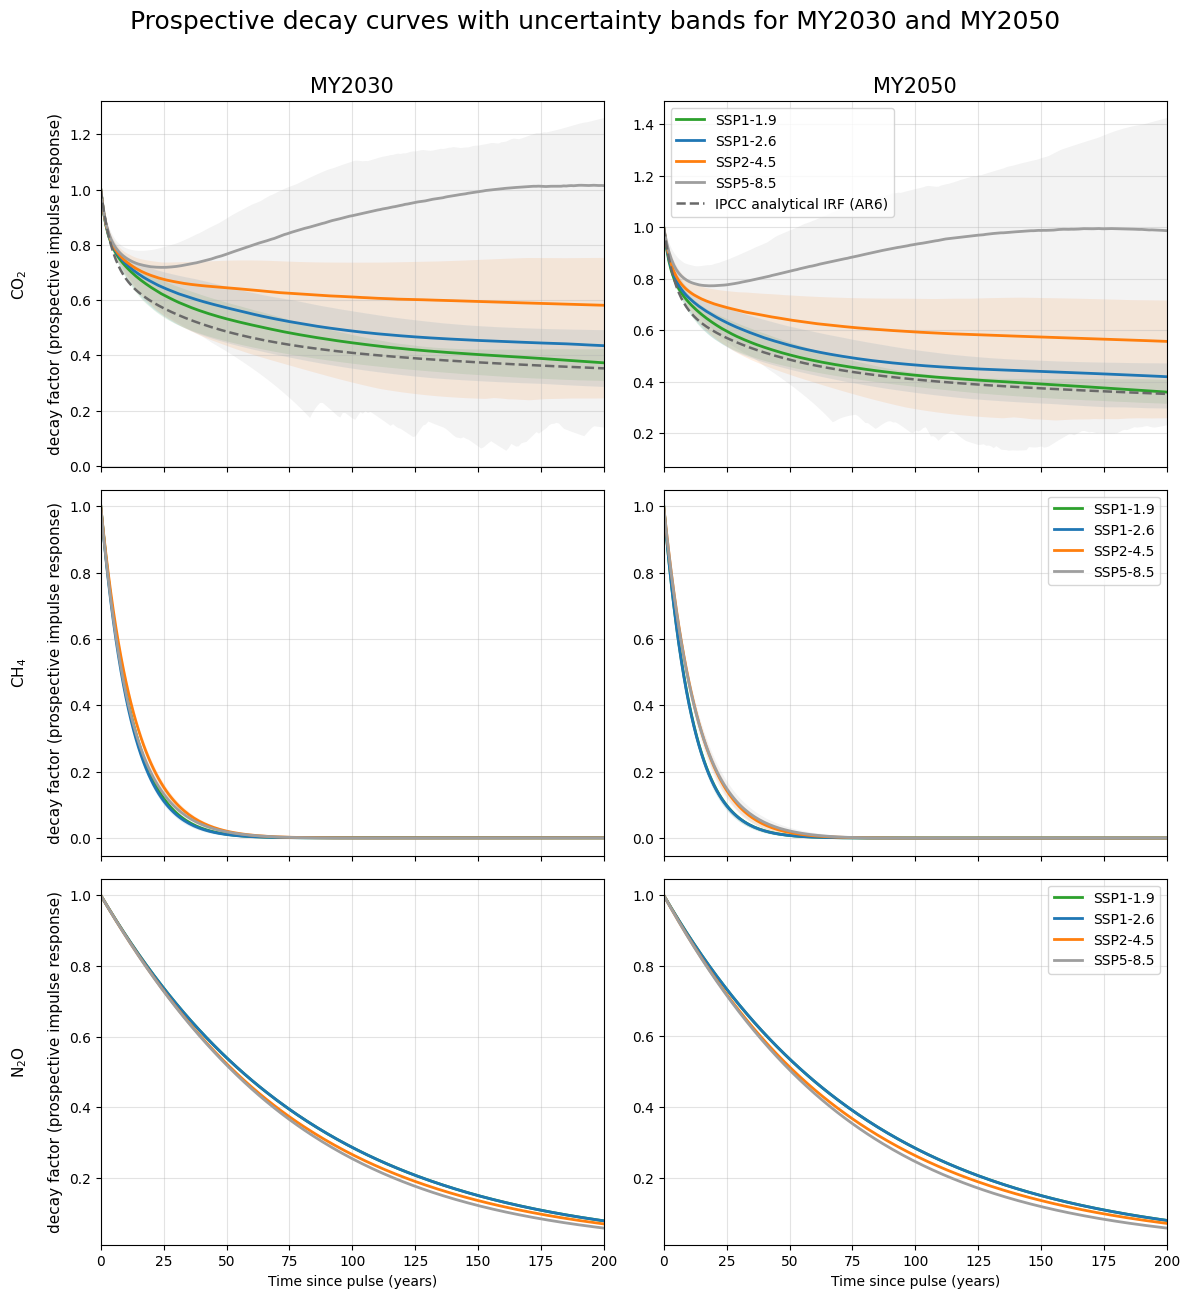

In [5]:
# ----------------------------
# Combined plot: 3 rows (gases) x 2 cols (MY2030, MY2050)
# ----------------------------
from pathlib import Path
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# choose the scenarios to plot
SCENARIOS = ["ssp119", "ssp126", "ssp245", "ssp585"]
GASES = ["CO2", "CH4", "N2O"]
MY_ORDER = ["2030", "2050"]

# ----------------------------
# Helpers
# ----------------------------
def detect_cols(df):
    df = df.copy()
    df.columns = [str(c) for c in df.columns]

    col_gas = [c for c in df.columns if c.lower() == "gas"][0]
    col_ssp = [c for c in df.columns if ("ssp" in c.lower()) or ("scenario" in c.lower())][0]
    col_h   = [c for c in df.columns if c.lower() in ["h", "horizon", "time", "t", "year"]][0]
    col_val = [c for c in df.columns if c.lower() in ["value", "median", "pirf"]][0]
    return col_gas, col_ssp, col_h, col_val

def gas_title(gas):
    return {"CO2": "CO$_2$", "CH4": "CH$_4$", "N2O": "N$_2$O"}[gas]

def get_median_line(year, gas, ssp, hmax=200):
    df = my_data[year]["df"]
    gcol = my_data[year]["gas"]
    scol = my_data[year]["ssp"]
    hcol = my_data[year]["h"]
    vcol = my_data[year]["val"]

    out = df[
        (df[gcol].astype(str).str.upper() == gas.upper()) &
        (df[scol].astype(str).str.lower() == ssp.lower())
    ].copy()
    out = out.sort_values(hcol)
    out = out[out[hcol] <= hmax]
    return out[hcol].to_numpy(), out[vcol].to_numpy()

def get_uncertainty_band(year, gas, ssp, h_len):
    ens = pirf_ens_all[year][ssp][gas]
    ens = np.asarray(ens)[:h_len, :]
    q_lo = np.quantile(ens, BAND_Q_LO, axis=1)
    q_hi = np.quantile(ens, BAND_Q_HI, axis=1)
    return q_lo, q_hi

# ----------------------------
# Load median tables for MY2030 and MY2050
# ----------------------------
my_data = {}
for year in MY_ORDER:
    path = paths_my[year]
    df = pd.read_excel(path, sheet_name="median_long")
    gcol, scol, hcol, vcol = detect_cols(df)
    my_data[year] = {
        "df": df,
        "gas": gcol,
        "ssp": scol,
        "h": hcol,
        "val": vcol,
    }

# ----------------------------
# Load ensemble tables for MY2030 and MY2050
# ----------------------------
pirf_ens_all = {}
for year in MY_ORDER:
    path = paths_my_ens[year]
    with open(path, "rb") as f:
        pirf_ens_all[year] = pickle.load(f)

print("Median data loaded for:", ", ".join(my_data.keys()))
print("Ensemble data loaded for:", ", ".join(pirf_ens_all.keys()))

# ----------------------------
# Plot: 3 rows (gases) x 2 cols (MY2030, MY2050)
# ----------------------------
fig, axes = plt.subplots(
    nrows=3, ncols=2, figsize=(12, 13), sharex=True
)

for r, gas in enumerate(GASES):
    for c, year in enumerate(MY_ORDER):
        ax = axes[r, c]

        for ssp in SCENARIOS:
            color = SCENARIO_COLORS[ssp]
            label = SCENARIO_LABELS[ssp]

            H, y = get_median_line(year, gas, ssp, hmax=H_MAX)
            q_lo, q_hi = get_uncertainty_band(year, gas, ssp, len(H))

            ax.fill_between(
                H, q_lo, q_hi,
                color=color, alpha=0.12, linewidth=0
            )
            ax.plot(
                H, y,
                color=color, linewidth=2.0, label=label
            )

        if gas == "CO2":
            ax.plot(
                H_ipcc, pIRF_ipcc,
                color="dimgray", linestyle="--", linewidth=1.8,
                label="IPCC analytical IRF (AR6)"
            )

        if r == 0:
            ax.set_title(f"MY{year}", fontsize=15)

        if c == 0:
            ax.set_ylabel(
                f"{gas_title(gas)}\n\ndecay factor (prospective impulse response)",
                fontsize=11
            )

        ax.set_xlim(0, H_MAX)
        ax.grid(True, alpha=0.35)

        # legend only on right column
        if c == 1:
            ax.legend(fontsize=10, ncol=1, frameon=True, loc="best")

for ax in axes[-1, :]:
    ax.set_xlabel("Time since pulse (years)")

fig.suptitle(
    "Prospective decay curves with uncertainty bands for MY2030 and MY2050",
    fontsize=18, y=0.995
)
fig.tight_layout(rect=[0, 0, 1, 0.985])

if SAVE_FIG:
    fig_path_png = out_dir / "pIRF_grid_uncertainty_IPCC_MY2030_2050.png"
    fig_path_pdf = out_dir / "pIRF_grid_uncertainty_IPCC_MY2030_2050.pdf"
    fig.savefig(fig_path_png, dpi=300, bbox_inches="tight")
    fig.savefig(fig_path_pdf, bbox_inches="tight")
    print("Saved figure to:")
    print(" -", fig_path_png)
    print(" -", fig_path_pdf)

plt.show()

### below just one MY2030 

Median data loaded for: 2030, 2040, 2050
Ensemble band loaded for BAND_MY = 2030
Saved figure to:
 - /Users/susierwu/dpLCA_main/dpLCIA/FaIR_dpCFs/output/pIRF/pIRF_plot_stacked_uncertainty_IPCC/pIRF_stacked_uncertainty_IPCC_MY2030.png
 - /Users/susierwu/dpLCA_main/dpLCIA/FaIR_dpCFs/output/pIRF/pIRF_plot_stacked_uncertainty_IPCC/pIRF_stacked_uncertainty_IPCC_MY2030.pdf


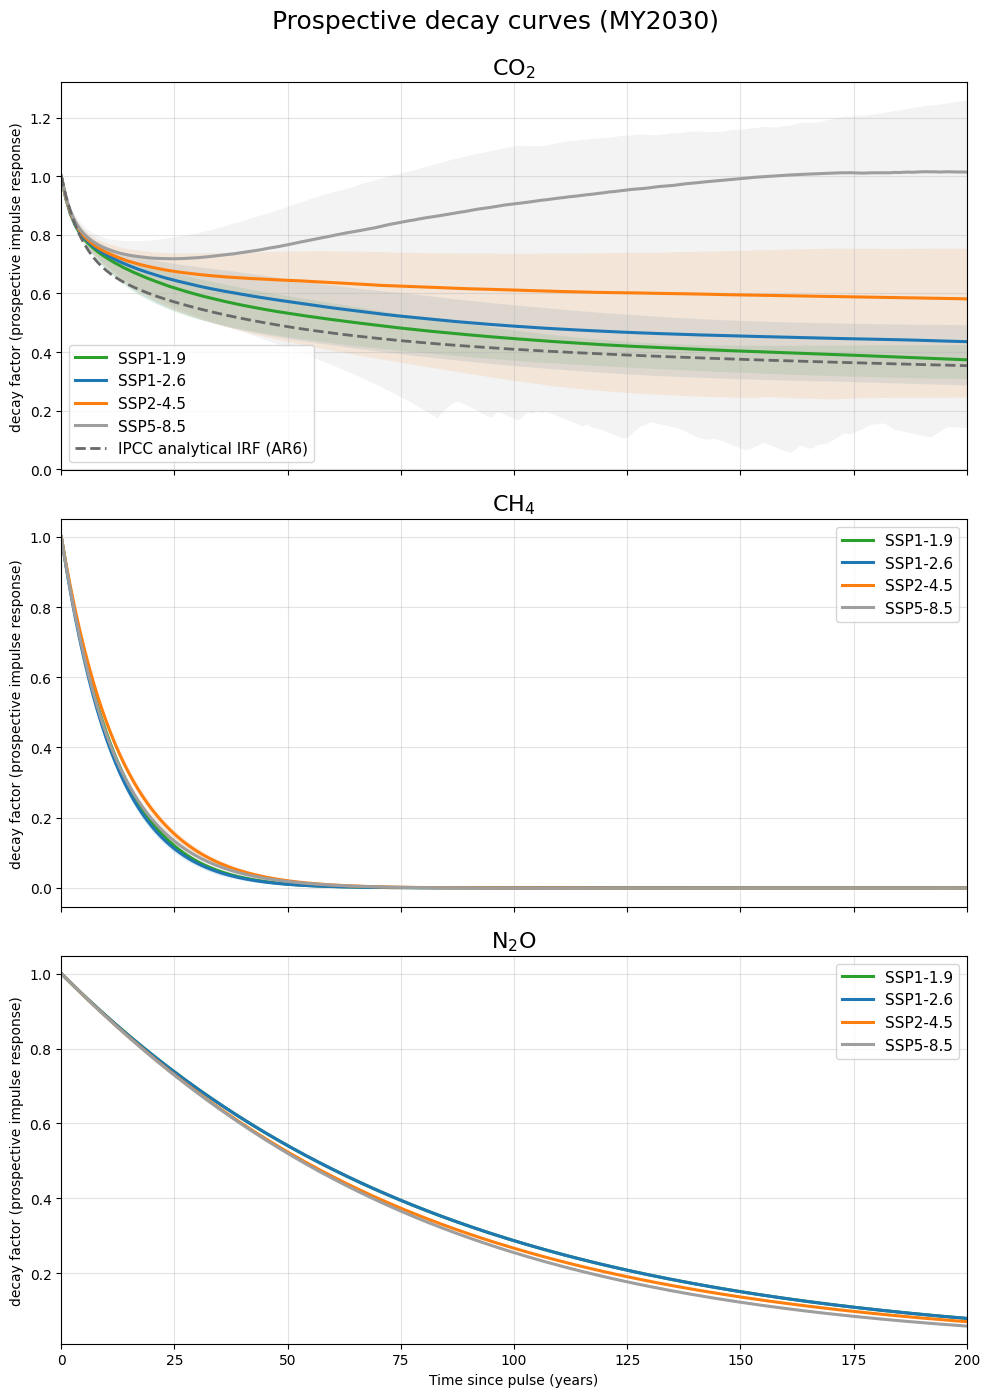

In [5]:

def detect_cols(df):
    df = df.copy()
    df.columns = [str(c) for c in df.columns]

    col_gas = [c for c in df.columns if c.lower() == "gas"][0]
    col_ssp = [c for c in df.columns if ("ssp" in c.lower()) or ("scenario" in c.lower())][0]
    col_h   = [c for c in df.columns if c.lower() in ["h", "horizon", "time", "t", "year"]][0]
    col_val = [c for c in df.columns if c.lower() in ["value", "median", "pirf"]][0]
    return col_gas, col_ssp, col_h, col_val

# load median tables
my_data = {}
for year, path in paths_my.items():
    df = pd.read_excel(path, sheet_name="median_long")
    gcol, scol, hcol, vcol = detect_cols(df)
    my_data[year] = {
        "df": df,
        "gas": gcol,
        "ssp": scol,
        "h": hcol,
        "val": vcol,
    }

# load ensemble table for selected ModelYear
with open(paths_my_ens[BAND_MY], "rb") as f:
    pirf_ens_band = pickle.load(f)

print("Median data loaded for:", ", ".join(my_data.keys()))
print("Ensemble band loaded for BAND_MY =", BAND_MY)



# ----------------------------
# Helper to extract median line
# ----------------------------
def get_median_line(year, gas, ssp, hmax=200):
    df = my_data[year]["df"]
    gcol = my_data[year]["gas"]
    scol = my_data[year]["ssp"]
    hcol = my_data[year]["h"]
    vcol = my_data[year]["val"]

    out = df[(df[gcol] == gas) & (df[scol].str.lower() == ssp)].copy()
    out = out.sort_values(hcol)
    out = out[out[hcol] <= hmax]
    return out[hcol].to_numpy(), out[vcol].to_numpy()

def get_uncertainty_band(gas, ssp, h_len):
    ens = pirf_ens_band[ssp][gas]
    ens = ens[:h_len, :]
    q_lo = np.quantile(ens, BAND_Q_LO, axis=1)
    q_hi = np.quantile(ens, BAND_Q_HI, axis=1)
    return q_lo, q_hi



# ----------------------------
# Plot
# ----------------------------
fig, axes = plt.subplots(
    nrows=3, ncols=1, figsize=(10, 14), sharex=True
)

for ax, gas in zip(axes, GASES):
    for ssp in SCENARIOS:
        color = SCENARIO_COLORS[ssp]
        label = SCENARIO_LABELS[ssp]

        H, y = get_median_line(BAND_MY, gas, ssp, hmax=H_MAX)
        q_lo, q_hi = get_uncertainty_band(gas, ssp, len(H))

        ax.fill_between(
            H, q_lo, q_hi,
            color=color, alpha=0.12, linewidth=0
        )
        ax.plot(
            H, y,
            color=color, linewidth=2.2, label=label
        )

    if gas == "CO2":
        ax.plot(
            H_ipcc, pIRF_ipcc,
            color="dimgray", linestyle="--", linewidth=2.0,
            label="IPCC analytical IRF (AR6)"
        )

    ax.set_title(
        {"CO2": "CO$_2$", "CH4": "CH$_4$", "N2O": "N$_2$O"}[gas],
        fontsize=16
    )
    ax.set_ylabel("decay factor (prospective impulse response)")
    ax.set_xlim(0, H_MAX)
    ax.grid(True, alpha=0.35)
    ax.legend(fontsize=11, ncol=1, frameon=True, loc="best")

axes[-1].set_xlabel("Time since pulse (years)")
fig.suptitle(
    f"Prospective decay curves (MY{BAND_MY})",
    fontsize=18, y=0.995
)
fig.tight_layout()

if SAVE_FIG:
    fig_path_png = out_dir / f"pIRF_stacked_uncertainty_IPCC_MY{BAND_MY}.png"
    fig_path_pdf = out_dir / f"pIRF_stacked_uncertainty_IPCC_MY{BAND_MY}.pdf"
    fig.savefig(fig_path_png, dpi=300, bbox_inches="tight")
    fig.savefig(fig_path_pdf, bbox_inches="tight")
    print("Saved figure to:")
    print(" -", fig_path_png)
    print(" -", fig_path_pdf)

plt.show()
